In [72]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as pyt 
import seaborn as sns 
import requests as requests
import warnings 
warnings.filterwarnings('ignore')

In [73]:
df = pd.read_csv('Data\WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [74]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [75]:
df.shape

(7043, 21)

In [76]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [77]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [79]:
df.duplicated().sum()

np.int64(0)

In [80]:
df_cleaned = df.drop(columns=["customerID"]).copy()

In [81]:
df_cleaned.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

<Axes: xlabel='Churn'>

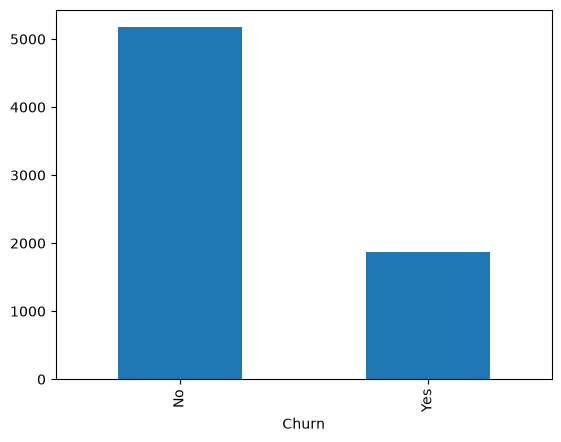

In [82]:
df_cleaned["Churn"].value_counts().plot(kind = 'bar')

<Axes: xlabel='Churn', ylabel='tenure'>

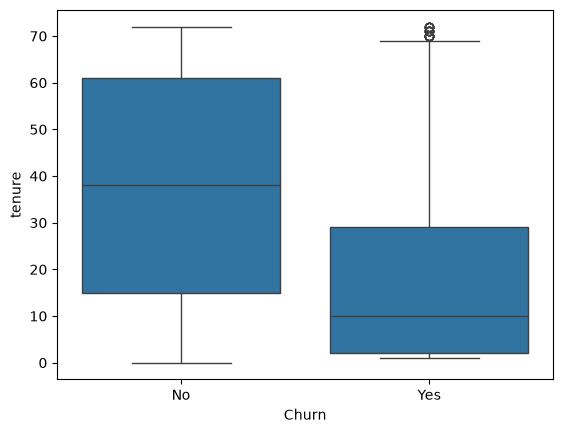

In [83]:
sns.boxplot(x = "Churn" , y = "tenure" , data= df_cleaned)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

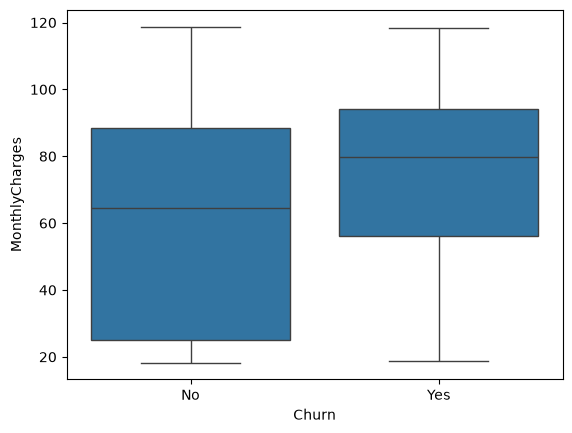

In [84]:
sns.boxplot(x = "Churn" , y = "MonthlyCharges" , data= df_cleaned)

In [85]:
df_cleaned["TotalCharges"] = pd.to_numeric(df_cleaned["TotalCharges"] , errors = "coerce")

In [86]:
# Keep categorical features as text until after the train/test split.

In [87]:
y = df_cleaned["Churn"].map({"Yes" : 1 , "No" : 0})
x = df_cleaned.drop('Churn', axis = 1)


In [88]:
# The encoder in cell 24 handles all categorical features after splitting.

In [89]:
y.value_counts(dropna=False)

Churn
0    5174
1    1869
Name: count, dtype: int64

In [90]:
x.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [91]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [92]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = ['tenure',	'MonthlyCharges',	'TotalCharges']

x[cols] = scaler.fit_transform(x[cols])


In [93]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [94]:
# Learn the replacement value from training data only.
training_mean = x_train["TotalCharges"].mean()
x_train["TotalCharges"] = x_train["TotalCharges"].fillna(training_mean)
x_test["TotalCharges"] = x_test["TotalCharges"].fillna(training_mean)

In [95]:
from sklearn.preprocessing import OneHotEncoder

# Discover categorical columns from training data only.
categorical_cols = x_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=int)

# Fit once on training data; reuse the learned categories for test data.
train_categories = encoder.fit_transform(x_train[categorical_cols])
test_categories = encoder.transform(x_test[categorical_cols])
encoded_columns = encoder.get_feature_names_out(categorical_cols)

# Preserve row indices so the encoded values stay with the correct customers.
x_train = pd.concat([
    x_train.drop(columns=categorical_cols),
    pd.DataFrame(train_categories, columns=encoded_columns, index=x_train.index)
], axis=1)
x_test = pd.concat([
    x_test.drop(columns=categorical_cols),
    pd.DataFrame(test_categories, columns=encoded_columns, index=x_test.index)
], axis=1)

x_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0,0.107048,-0.517207,-0.256617,0,1,1,0,1,0,...,1,1,0,0,1,0,0,0,1,0
3151,0,-0.707359,0.343603,-0.499314,0,1,0,1,0,1,...,0,1,0,0,1,0,0,0,0,1
4860,0,-0.788800,-0.804698,-0.746909,0,1,0,1,0,1,...,0,0,0,1,1,0,0,0,0,1
3867,0,-0.259435,0.290426,-0.166593,1,0,0,1,1,0,...,1,0,0,1,0,1,0,1,0,0
3810,0,-1.277445,-0.671755,-0.987709,0,1,0,1,0,1,...,0,1,0,0,1,0,0,0,1,0


In [97]:
x_train

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0,0.107048,-0.517207,-0.256617,0,1,1,0,1,0,...,1,1,0,0,1,0,0,0,1,0
3151,0,-0.707359,0.343603,-0.499314,0,1,0,1,0,1,...,0,1,0,0,1,0,0,0,0,1
4860,0,-0.788800,-0.804698,-0.746909,0,1,0,1,0,1,...,0,0,0,1,1,0,0,0,0,1
3867,0,-0.259435,0.290426,-0.166593,1,0,0,1,1,0,...,1,0,0,1,0,1,0,1,0,0
3810,0,-1.277445,-0.671755,-0.987709,0,1,0,1,0,1,...,0,1,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,0,1.572981,1.478611,2.393177,1,0,0,1,1,0,...,1,0,0,1,1,0,0,0,1,0
6227,0,-1.236724,-0.621901,-0.971914,0,1,1,0,1,0,...,0,1,0,0,1,0,1,0,0,0
4673,1,-0.300156,1.264239,0.166283,1,0,1,0,1,0,...,1,1,0,0,0,1,0,0,0,1
2710,0,-0.340876,-1.474403,-0.794358,1,0,0,1,1,0,...,0,0,1,0,1,0,0,1,0,0
